![Plan of action](images/advance_chatbot_plan.png)


This is whole plan of an advance ChatBot which will have features like -
 - chatting
 - RAG
    - memore. persitence, Human in the loop (HIL), Retry
 - Tools calling
 - UI
 - LangSmith for logging

This notebook is a chatbot with persistence

### This notebook is an implementation of a simple chatbot with 

![workflow](images/chatbot1.png)

In [3]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START,END, add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage,HumanMessage



When we talk to an LLM we talk via messages. In the LangChain there a few types of messages. 

user: "What is the capital of India?" -> this is HumanMessage
AI: "New Delhi" -> AIMessage

SystemMessage : to specify a role to an LLM ( is defined by use)
ToolMessage : to define a definition for a tool called by an LLM

Above four types of messages inheret from BaseMessage. 

In [4]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]  # it contains any types of messages


In [5]:
llm = ChatOpenAI()

In [13]:
def chat_node(state: ChatState):

    message = state['messages']

    response = llm.invoke(message)

    return {'messages': [response]}

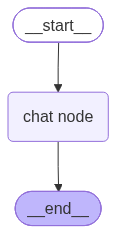

In [14]:
graph = StateGraph(ChatState)

graph.add_node("chat node", chat_node)

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

chatbot = graph.compile()

chatbot

In [16]:
initial_state = {
    "messages": [HumanMessage(content="what is capital of India?")]
    }

responses = chatbot.invoke(initial_state)
responses

{'messages': [HumanMessage(content='what is capital of India?', additional_kwargs={}, response_metadata={}, id='b2bb4983-c8c4-42eb-81c9-3f3d8ad57ef4'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EAROXy3awSvCXfehRiyGAxfqahBBS', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fdf45-5d35-7150-8db7-73ae1937f3fe-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_d

In [20]:
# building a loop for continuous chatting

while True:

    user_input = input("What to ask?")
    print(f"user:{user_input}")

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        break

    initial_messages ={
        'messages': [HumanMessage(content=user_input)]
    }
    response = chatbot.invoke(initial_messages)

    print(f'AI: {response['messages'][-1].content}')


user:I am Bani
AI: Hello Bani! How can I assist you today?
user:What is my name?
AI: I'm sorry, but I do not have access to your personal information and cannot determine your name.
user:bye


**Failure Case**
- in the above example as we can see this chatbot does not have any memory, as a result it fails to answer connected question.
But from the above workflow, we aare adding all the previous messages, so it should have all the related information.
- we need to keep in mind that at each invokation,  sate values get reset. This is the same thing happening over here. 
- first time user : I am Bani. And LLM generates the corresponding output. 
- Now when user asking " what is my name ?", this is another invokation and LLM does not have information about previous conversation. 

To solve this we need to implement persistence memory, which stores all the information and feed model bofore it starts generating any response. 
- we can save the memory in RAM or remote DB. 
- here we will use RAM to save information

In [21]:
from langgraph.checkpoint.memory import MemorySaver # to save information in the RAM



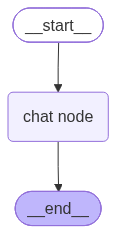

In [22]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat node", chat_node)

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [23]:

thread_id = "1" # providing id for a particular user
while True:

    user_input = input("What to ask?")
    print(f"user:{user_input}")

    if user_input.strip().lower() in ['exit', 'quit', 'bye']:
        break

    initial_messages ={
        'messages': [HumanMessage(content=user_input)]
    }
    config = {'configurable':{'thread_id':thread_id}}

    response = chatbot.invoke(initial_messages, config= config)

    print(f'AI: {response['messages'][-1].content}')

user:Hi I am Bani
AI: Hello Bani! How can I assist you today?
user:what is my name?
AI: Your name is Bani. Is there anything else you would like to know or talk about?
user:bye


*see now this workflow is working perfectly and can response properly according to the previous conversation*

In [24]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi I am Bani', additional_kwargs={}, response_metadata={}, id='48f0a85f-75a0-481d-99c0-8a52be42f56c'), AIMessage(content='Hello Bani! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 12, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-EAUFkPU3FChWmperTi50z0IJVosse', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fdfec-fefc-7f30-b8aa-e8e02f2550d2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 11, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o